Trạng thái ban đầu: Chỉ nút 0 bị tắc (Màu đỏ)


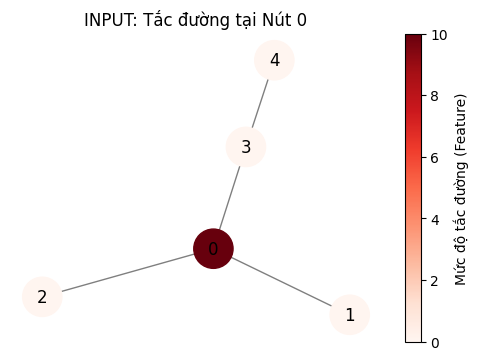

In [1]:
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from gcn import GCN, normalize_adj  # Import file gcn.py bạn vừa viết

# Hàm vẽ đồ thị để dễ nhìn
def plot_graph(adj, features, title):
    # Tạo đồ thị từ ma trận kề
    rows, cols = np.where(adj > 0)
    edges = zip(rows.tolist(), cols.tolist())
    G = nx.Graph()
    G.add_edges_from(edges)
    
    # Lấy giá trị đặc trưng để tô màu (màu càng đậm -> tắc càng nặng)
    values = features.flatten()
    
    plt.figure(figsize=(6, 4))
    pos = nx.spring_layout(G, seed=42) # Cố định vị trí các nút
    
    # Vẽ nút
    nodes = nx.draw_networkx_nodes(G, pos, node_color=values, 
                                 cmap=plt.cm.Reds, vmin=0, vmax=10, node_size=800)
    # Vẽ cạnh
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    # Vẽ nhãn (số thứ tự nút)
    nx.draw_networkx_labels(G, pos, font_color='black')
    
    plt.colorbar(nodes, label='Mức độ tắc đường (Feature)')
    plt.title(title)
    plt.axis('off')
    plt.show()

# --- BẮT ĐẦU TEST ---

# 1. Tạo 1 mạng lưới nhỏ: Nút 0 nối với 1, 2, 3. Nút 4 đứng xa nối với 3.
# Ma trận kề (5 nút)
num_nodes = 5
adj = np.array([
    [0, 1, 1, 1, 0], # 0 nối với 1, 2, 3
    [1, 0, 0, 0, 0], # 1 chỉ nối với 0
    [1, 0, 0, 0, 0], # 2 chỉ nối với 0
    [1, 0, 0, 0, 1], # 3 nối với 0 và 4
    [0, 0, 0, 1, 0]  # 4 chỉ nối với 3
])

# 2. Tạo dữ liệu "Vụ tắc đường tại Nút 0"
# Feature ban đầu: Nút 0 có giá trị 10 (Tắc), các nút khác = 0
x = torch.zeros(1, num_nodes, 1) # (Batch, Nodes, Features)
x[0, 0, 0] = 10.0 

# Vẽ trạng thái ban đầu
print("Trạng thái ban đầu: Chỉ nút 0 bị tắc (Màu đỏ)")
plot_graph(adj, x[0].numpy(), "INPUT: Tắc đường tại Nút 0")

Trạng thái sau GCN: Sự tắc đường đã lan ra hàng xóm!


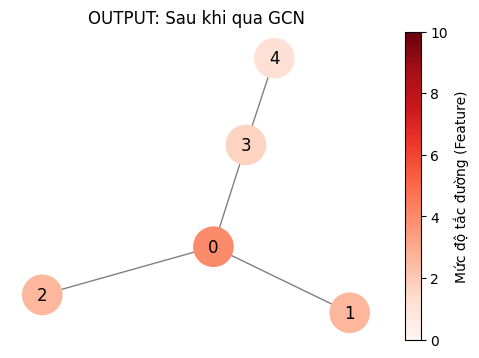

In [2]:
# 3. Chuẩn bị mô hình
# Ta hack nhẹ vào weight để dễ hiểu: Set Weight = 1, Bias = 0
# Để xem thuần túy việc "cộng gộp hàng xóm" diễn ra thế nào
model = GCN(in_features=1, hidden_features=1, out_features=1)
with torch.no_grad():
    model.gc1.weight.fill_(1.0) # Trọng số = 1
    model.gc1.bias.fill_(0.0)
    model.gc2.weight.fill_(1.0)
    model.gc2.bias.fill_(0.0)

# 4. Chuẩn bị Ma trận kề chuẩn hóa (Bắt buộc)
adj_norm = normalize_adj(adj)
adj_tensor = torch.FloatTensor(adj_norm)

# 5. CHẠY MODEL (Forward Pass)
model.eval()
output = model(x, adj_tensor)

# Vẽ kết quả
print("Trạng thái sau GCN: Sự tắc đường đã lan ra hàng xóm!")
plot_graph(adj, output.detach()[0].numpy(), "OUTPUT: Sau khi qua GCN")